# Mutual Fund Performance Analytics

This notebook implements a complete mutual fund performance analytics workflow.

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import os
import warnings

warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('ggplot')

# Define Constants
RF_RATE = 0.065
TRADING_DAYS = 252

# Ensure outputs directory
OUTPUT_DIR = '.'

## PHASE 1: DATA DISCOVERY AND VALIDATION

In [2]:
# Load Datasets
print("Loading datasets...")
nav_df = pd.read_csv('data/processed/nav_history_clean.csv', parse_dates=['date'])
benchmarks_df = pd.read_csv('data/processed/benchmark_indices_clean.csv', parse_dates=['date'])
fund_master = pd.read_csv('data/processed/fund_master_clean.csv')

# Data Validation Summary
print("\n--- Data Validation Summary ---")
print(f"NAV Data: Rows={len(nav_df)}, Cols={len(nav_df.columns)}, Unique Funds={nav_df['amfi_code'].nunique()}")
print(f"NAV Date Range: {nav_df['date'].min().date()} to {nav_df['date'].max().date()}")
print(f"NAV Missing Values:\n{nav_df.isnull().sum()}")

print(f"\nBenchmarks: Rows={len(benchmarks_df)}, Cols={len(benchmarks_df.columns)}, Unique Indices={benchmarks_df['index_name'].nunique()}")
print(f"Benchmark Missing Values:\n{benchmarks_df.isnull().sum()}")

print(f"\nFund Master: Rows={len(fund_master)}, Cols={len(fund_master.columns)}")

# Validations
print("\n--- Validations ---")
assert (nav_df['nav'] > 0).all(), "Found non-positive NAV values"
assert nav_df['date'].notna().all(), "Found unparseable dates in NAV"
assert benchmarks_df['date'].notna().all(), "Found unparseable dates in Benchmarks"
assert pd.api.types.is_numeric_dtype(fund_master['expense_ratio_pct']), "Expense ratios are not numeric"

print("All validations passed.")

Loading datasets...

--- Data Validation Summary ---
NAV Data: Rows=46000, Cols=3, Unique Funds=40
NAV Date Range: 2022-01-03 to 2026-05-29
NAV Missing Values:
amfi_code    0
date         0
nav          0
dtype: int64

Benchmarks: Rows=8050, Cols=3, Unique Indices=7
Benchmark Missing Values:
date           0
index_name     0
close_value    0
dtype: int64

Fund Master: Rows=40, Cols=15

--- Validations ---
All validations passed.


## PHASE 2: DAILY RETURN CALCULATION

In [3]:
# Sort data
nav_df = nav_df.sort_values(['amfi_code', 'date'])

# Calculate daily returns
nav_df['daily_return'] = nav_df.groupby('amfi_code')['nav'].pct_change()

# Remove first NaN observations
nav_df = nav_df.dropna(subset=['daily_return'])

# Generate validation statistics
return_stats = nav_df.groupby('amfi_code')['daily_return'].agg([
    'mean', 'median', 'std', 'min', 'max', 'count'
]).reset_index()

# Merge with fund names
return_stats = pd.merge(return_stats, fund_master[['amfi_code', 'scheme_name']], on='amfi_code', how='left')

print("Daily Return Statistics Sample:")
print(return_stats.head())

Daily Return Statistics Sample:
   amfi_code      mean    median       std       min       max  count  \
0     100016  0.000142 -0.000070  0.009164 -0.024744  0.032145   1149   
1     100025  0.000170  0.000099  0.002460 -0.008188  0.008837   1149   
2     100033  0.001080  0.001086  0.011929 -0.044238  0.041954   1149   
3     101206  0.000852  0.000808  0.009177 -0.038121  0.033956   1149   
4     101207  0.000424  0.000182  0.016251 -0.051847  0.054851   1149   

                                         scheme_name  
0          HDFC Top 100 Fund - Regular Plan - Growth  
1       HDFC Short Term Debt Fund - Regular - Growth  
2  HDFC Mid-Cap Opportunities Fund - Regular - Gr...  
3      ABSL Frontline Equity Fund - Regular - Growth  
4             ABSL Small Cap Fund - Regular - Growth  


## PHASE 3: CAGR CALCULATIONS

In [4]:
def calculate_cagr(start_val, end_val, years):
    if years <= 0 or pd.isna(start_val) or pd.isna(end_val) or start_val <= 0:
        return np.nan
    return (end_val / start_val) ** (1 / years) - 1

cagr_data = []

for amfi, group in nav_df.groupby('amfi_code'):
    group = group.sort_values('date')
    if group.empty:
        continue
        
    end_date = group['date'].iloc[-1]
    end_nav = group['nav'].iloc[-1]
    
    # 1 Year
    start_date_1y = end_date - pd.DateOffset(years=1)
    past_1y = group[group['date'] <= start_date_1y]
    cagr_1y = np.nan
    if not past_1y.empty:
        start_nav_1y = past_1y['nav'].iloc[-1]
        cagr_1y = calculate_cagr(start_nav_1y, end_nav, 1)
        
    # 3 Year
    start_date_3y = end_date - pd.DateOffset(years=3)
    past_3y = group[group['date'] <= start_date_3y]
    cagr_3y = np.nan
    if not past_3y.empty:
        start_nav_3y = past_3y['nav'].iloc[-1]
        cagr_3y = calculate_cagr(start_nav_3y, end_nav, 3)
        
    # 5 Year
    start_date_5y = end_date - pd.DateOffset(years=5)
    past_5y = group[group['date'] <= start_date_5y]
    cagr_5y = np.nan
    if not past_5y.empty:
        start_nav_5y = past_5y['nav'].iloc[-1]
        cagr_5y = calculate_cagr(start_nav_5y, end_nav, 5)
        
    cagr_data.append({
        'amfi_code': amfi,
        '1Y CAGR': cagr_1y,
        '3Y CAGR': cagr_3y,
        '5Y CAGR': cagr_5y
    })

cagr_df = pd.DataFrame(cagr_data)
cagr_df = pd.merge(cagr_df, fund_master[['amfi_code', 'scheme_name']], on='amfi_code', how='left')

# Rankings based on 3Y CAGR
cagr_df['3Y_CAGR_Rank'] = cagr_df['3Y CAGR'].rank(ascending=False)

print("CAGR Table Sample:")
print(cagr_df[['scheme_name', '1Y CAGR', '3Y CAGR', '5Y CAGR']].head())

CAGR Table Sample:
                                         scheme_name   1Y CAGR   3Y CAGR  \
0          HDFC Top 100 Fund - Regular Plan - Growth -0.022243  0.012926   
1       HDFC Short Term Debt Fund - Regular - Growth  0.037050  0.039164   
2  HDFC Mid-Cap Opportunities Fund - Regular - Gr...  0.532324  0.324425   
3      ABSL Frontline Equity Fund - Regular - Growth  0.479241  0.289677   
4             ABSL Small Cap Fund - Regular - Growth -0.239860 -0.041524   

   5Y CAGR  
0      NaN  
1      NaN  
2      NaN  
3      NaN  
4      NaN  


## PHASE 4: SHARPE RATIO

In [5]:
sharpe_data = []

for amfi, group in nav_df.groupby('amfi_code'):
    returns = group['daily_return'].dropna()
    if len(returns) < TRADING_DAYS:
        continue
        
    ann_return = returns.mean() * TRADING_DAYS
    ann_vol = returns.std() * np.sqrt(TRADING_DAYS)
    
    if ann_vol > 0:
        sharpe = (ann_return - RF_RATE) / ann_vol
    else:
        sharpe = np.nan
        
    sharpe_data.append({
        'amfi_code': amfi,
        'Ann_Return': ann_return,
        'Ann_Vol': ann_vol,
        'Sharpe': sharpe
    })

sharpe_df = pd.DataFrame(sharpe_data)
sharpe_df = pd.merge(sharpe_df, fund_master[['amfi_code', 'scheme_name']], on='amfi_code', how='left')
sharpe_df['Sharpe_Rank'] = sharpe_df['Sharpe'].rank(ascending=False)

print("Sharpe Ratio Sample:")
print(sharpe_df.sort_values('Sharpe', ascending=False)[['scheme_name', 'Sharpe']].head())

Sharpe Ratio Sample:
                                      scheme_name    Sharpe
34  Mirae Asset Large Cap Fund - Regular - Growth  1.448291
30         Kotak Flexicap Fund - Regular - Growth  1.306744
36  Mirae Asset Tax Saver Fund - Regular - Growth  1.234930
19      SBI Bluechip Fund - Regular Plan - Growth  1.208267
25       ICICI Pru Midcap Fund - Regular - Growth  1.180101


## PHASE 5: SORTINO RATIO

In [6]:
sortino_data = []

for amfi, group in nav_df.groupby('amfi_code'):
    returns = group['daily_return'].dropna()
    if len(returns) < TRADING_DAYS:
        continue
        
    ann_return = returns.mean() * TRADING_DAYS
    
    negative_returns = returns[returns < 0]
    if len(negative_returns) > 0:
        downside_dev = np.sqrt(np.mean(negative_returns**2)) * np.sqrt(TRADING_DAYS)
        sortino = (ann_return - RF_RATE) / downside_dev if downside_dev > 0 else np.nan
    else:
        sortino = np.nan
        
    sortino_data.append({
        'amfi_code': amfi,
        'Sortino': sortino
    })

sortino_df = pd.DataFrame(sortino_data)
ratio_df = pd.merge(sharpe_df[['amfi_code', 'scheme_name', 'Sharpe']], sortino_df, on='amfi_code')

print("Risk Ratios Sample:")
print(ratio_df.head())

Risk Ratios Sample:
   amfi_code                                        scheme_name    Sharpe  \
0     100016          HDFC Top 100 Fund - Regular Plan - Growth -0.201517   
1     100025       HDFC Short Term Debt Fund - Regular - Growth -0.567095   
2     100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...  1.093699   
3     101206      ABSL Frontline Equity Fund - Regular - Growth  1.027213   
4     101207             ABSL Small Cap Fund - Regular - Growth  0.162661   

    Sortino  
0 -0.208477  
1 -0.587360  
2  1.136584  
3  1.083847  
4  0.166070  


## PHASE 6: ALPHA AND BETA

In [7]:
# Benchmark: Nifty 100
nifty100 = benchmarks_df[benchmarks_df['index_name'] == 'NIFTY100'].copy()
nifty100 = nifty100.sort_values('date')
nifty100['bench_return'] = nifty100['close_value'].pct_change()
nifty100 = nifty100.dropna(subset=['bench_return'])

alpha_beta_data = []

for amfi, group in nav_df.groupby('amfi_code'):
    merged = pd.merge(group[['date', 'daily_return']], nifty100[['date', 'bench_return']], on='date', how='inner')
    merged = merged.dropna()
    
    if len(merged) < 30: # Need enough data points
        continue
        
    x = merged['bench_return']
    y = merged['daily_return']
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    
    beta = slope
    ann_alpha = intercept * TRADING_DAYS
    
    alpha_beta_data.append({
        'amfi_code': amfi,
        'Alpha': ann_alpha,
        'Beta': beta,
        'R_squared': r_value**2,
        'p_value': p_value,
        'std_error': std_err
    })

ab_df = pd.DataFrame(alpha_beta_data)
ab_df = pd.merge(ab_df, fund_master[['amfi_code', 'scheme_name']], on='amfi_code', how='left')

# Reorder columns
ab_df = ab_df[['scheme_name', 'Alpha', 'Beta', 'R_squared', 'p_value', 'std_error', 'amfi_code']]

ab_df.to_csv('alpha_beta.csv', index=False)
print("Alpha and Beta calculated and saved to alpha_beta.csv")
print(ab_df[['scheme_name', 'Alpha', 'Beta']].head())

Alpha and Beta calculated and saved to alpha_beta.csv
                                         scheme_name     Alpha      Beta
0          HDFC Top 100 Fund - Regular Plan - Growth  0.037476 -0.058268
1       HDFC Short Term Debt Fund - Regular - Growth  0.042818  0.001158
2  HDFC Mid-Cap Opportunities Fund - Regular - Gr...  0.271954  0.005104
3      ABSL Frontline Equity Fund - Regular - Growth  0.213998  0.021086
4             ABSL Small Cap Fund - Regular - Growth  0.108971 -0.065289


## PHASE 7: MAXIMUM DRAWDOWN

In [8]:
drawdown_data = []

for amfi, group in nav_df.groupby('amfi_code'):
    group = group.sort_values('date')
    group['running_max'] = group['nav'].cummax()
    group['drawdown'] = group['nav'] / group['running_max'] - 1
    
    min_drawdown = group['drawdown'].min()
    min_dd_idx = group['drawdown'].idxmin()
    
    trough_date = group.loc[min_dd_idx, 'date']
    
    # Peak before trough
    peak_date = group[(group['date'] <= trough_date) & (group['nav'] == group.loc[min_dd_idx, 'running_max'])]['date'].max()
    
    # Recovery
    recovery_df = group[(group['date'] > trough_date) & (group['nav'] >= group.loc[min_dd_idx, 'running_max'])]
    recovery_date = recovery_df['date'].min() if not recovery_df.empty else pd.NaT
    
    drawdown_data.append({
        'amfi_code': amfi,
        'Max_Drawdown': min_drawdown,
        'Peak_Date': peak_date,
        'Trough_Date': trough_date,
        'Recovery_Date': recovery_date
    })

dd_df = pd.DataFrame(drawdown_data)
dd_df = pd.merge(dd_df, fund_master[['amfi_code', 'scheme_name']], on='amfi_code', how='left')
dd_df['Drawdown_Period'] = (dd_df['Trough_Date'] - dd_df['Peak_Date']).dt.days

print("Max Drawdown Sample:")
print(dd_df.sort_values('Max_Drawdown')[['scheme_name', 'Max_Drawdown', 'Drawdown_Period']].head())

Max Drawdown Sample:
                                   scheme_name  Max_Drawdown  Drawdown_Period
22   SBI Small Cap Fund - Direct Plan - Growth     -0.525742             1015
17      Axis Small Cap Fund - Regular - Growth     -0.516778              354
4       ABSL Small Cap Fund - Regular - Growth     -0.354469              536
39       DSP Small Cap Fund - Regular - Growth     -0.311719              245
21  SBI Small Cap Fund - Regular Plan - Growth     -0.287060              259


## PHASE 8: FUND SCORECARD

In [9]:
# Merge required metrics
scorecard = pd.merge(cagr_df[['amfi_code', 'scheme_name', '3Y CAGR']], sharpe_df[['amfi_code', 'Sharpe']], on='amfi_code', how='left')
scorecard = pd.merge(scorecard, ab_df[['amfi_code', 'Alpha']], on='amfi_code', how='left')
scorecard = pd.merge(scorecard, fund_master[['amfi_code', 'expense_ratio_pct']], on='amfi_code', how='left')
scorecard = pd.merge(scorecard, dd_df[['amfi_code', 'Max_Drawdown']], on='amfi_code', how='left')

# Drop NA rows to compute percentiles properly
scorecard = scorecard.dropna(subset=['3Y CAGR', 'Sharpe', 'Alpha', 'expense_ratio_pct', 'Max_Drawdown'])

# Rank metrics (percentile score 0 to 1)
# Higher is better for CAGR, Sharpe, Alpha
scorecard['cagr_pct'] = scorecard['3Y CAGR'].rank(pct=True)
scorecard['sharpe_pct'] = scorecard['Sharpe'].rank(pct=True)
scorecard['alpha_pct'] = scorecard['Alpha'].rank(pct=True)

# Lower is better for Expense Ratio and Drawdown (Drawdown is negative, so higher value is smaller drawdown)
scorecard['exp_pct'] = scorecard['expense_ratio_pct'].rank(pct=True, ascending=False)
scorecard['dd_pct'] = scorecard['Max_Drawdown'].rank(pct=True) 

# Calculate composite score (0-100)
scorecard['Final Score'] = (
    0.30 * scorecard['cagr_pct'] +
    0.25 * scorecard['sharpe_pct'] +
    0.20 * scorecard['alpha_pct'] +
    0.15 * scorecard['exp_pct'] +
    0.10 * scorecard['dd_pct']
) * 100

scorecard = scorecard.sort_values('Final Score', ascending=False)
scorecard['Overall Rank'] = scorecard['Final Score'].rank(ascending=False).astype(int)

# Create Output DataFrame
output_scorecard = pd.DataFrame({
    'Fund Name': scorecard['scheme_name'],
    '3Y CAGR Score': (scorecard['cagr_pct'] * 100).round(2),
    'Sharpe Score': (scorecard['sharpe_pct'] * 100).round(2),
    'Alpha Score': (scorecard['alpha_pct'] * 100).round(2),
    'Expense Score': (scorecard['exp_pct'] * 100).round(2),
    'Drawdown Score': (scorecard['dd_pct'] * 100).round(2),
    'Final Score': scorecard['Final Score'].round(2),
    'Overall Rank': scorecard['Overall Rank']
})

output_scorecard.to_csv('fund_scorecard.csv', index=False)
print("Scorecard saved to fund_scorecard.csv")
print(output_scorecard.head())

Scorecard saved to fund_scorecard.csv
                                            Fund Name  3Y CAGR Score  \
34      Mirae Asset Large Cap Fund - Regular - Growth           97.5   
25           ICICI Pru Midcap Fund - Regular - Growth           90.0   
30             Kotak Flexicap Fund - Regular - Growth           85.0   
2   HDFC Mid-Cap Opportunities Fund - Regular - Gr...           92.5   
24          ICICI Pru Bluechip Fund - Direct - Growth           95.0   

    Sharpe Score  Alpha Score  Expense Score  Drawdown Score  Final Score  \
34         100.0         85.0           45.0            82.5        86.25   
25          90.0         95.0           65.0            40.0        82.25   
30          97.5         90.0           47.5            70.0        82.00   
2           85.0         87.5           60.0            52.5        80.75   
24          77.5         70.0           72.5            72.5        80.00   

    Overall Rank  
34             1  
25             2  
30       

## PHASE 9: TOP FUND IDENTIFICATION

In [10]:
top_5_funds = output_scorecard.head(5)['Fund Name'].tolist()
top_5_amfi = scorecard.head(5)['amfi_code'].tolist()

print("Top 5 Funds:")
for f in top_5_funds:
    print(f"- {f}")

Top 5 Funds:
- Mirae Asset Large Cap Fund - Regular - Growth
- ICICI Pru Midcap Fund - Regular - Growth
- Kotak Flexicap Fund - Regular - Growth
- HDFC Mid-Cap Opportunities Fund - Regular - Growth
- ICICI Pru Bluechip Fund - Direct - Growth


## PHASE 10: BENCHMARK COMPARISON

Chart saved as benchmark_comparison.png


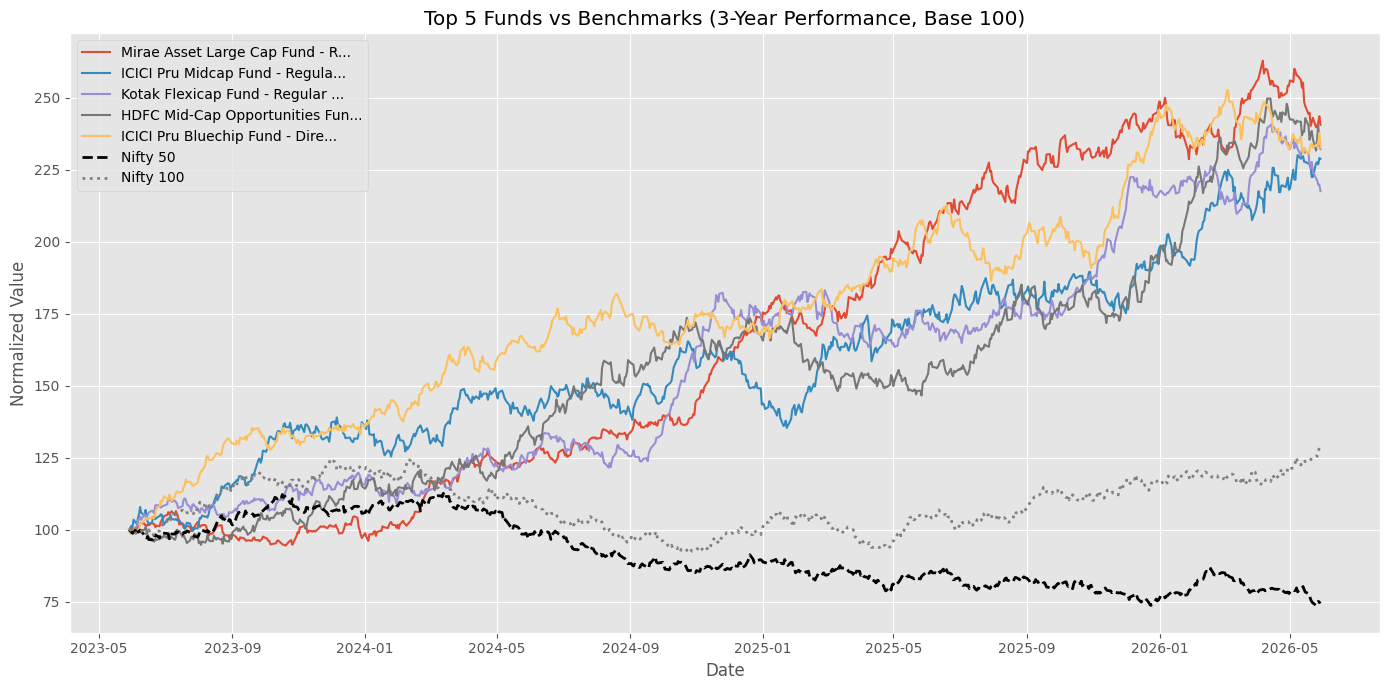

In [11]:
# Most recent 3 years
max_date = nav_df['date'].max()
start_3y_date = max_date - pd.DateOffset(years=3)

# Filter 3Y Data
nav_3y = nav_df[(nav_df['date'] >= start_3y_date) & (nav_df['amfi_code'].isin(top_5_amfi))]

nifty50_3y = benchmarks_df[(benchmarks_df['index_name'] == 'NIFTY50') & (benchmarks_df['date'] >= start_3y_date)]
nifty100_3y = benchmarks_df[(benchmarks_df['index_name'] == 'NIFTY100') & (benchmarks_df['date'] >= start_3y_date)]

plt.figure(figsize=(14, 7))

# Plot Funds
for amfi in top_5_amfi:
    fund_data = nav_3y[nav_3y['amfi_code'] == amfi].sort_values('date')
    if not fund_data.empty:
        fund_name = fund_master[fund_master['amfi_code'] == amfi]['scheme_name'].values[0]
        base_nav = fund_data['nav'].iloc[0]
        normalized_nav = (fund_data['nav'] / base_nav) * 100
        plt.plot(fund_data['date'], normalized_nav, label=fund_name[:30] + '...')

# Plot Benchmarks
if not nifty50_3y.empty:
    nifty50_3y = nifty50_3y.sort_values('date')
    base_val = nifty50_3y['close_value'].iloc[0]
    norm_val = (nifty50_3y['close_value'] / base_val) * 100
    plt.plot(nifty50_3y['date'], norm_val, label='Nifty 50', color='black', linewidth=2, linestyle='--')

if not nifty100_3y.empty:
    nifty100_3y = nifty100_3y.sort_values('date')
    base_val = nifty100_3y['close_value'].iloc[0]
    norm_val = (nifty100_3y['close_value'] / base_val) * 100
    plt.plot(nifty100_3y['date'], norm_val, label='Nifty 100', color='gray', linewidth=2, linestyle=':')

plt.title('Top 5 Funds vs Benchmarks (3-Year Performance, Base 100)')
plt.xlabel('Date')
plt.ylabel('Normalized Value')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.savefig('benchmark_comparison.png')
print("Chart saved as benchmark_comparison.png")

## PHASE 11: TRACKING ERROR

In [12]:
te_data = []

# Prepare Benchmarks Returns
n50_ret = nifty50_3y[['date', 'close_value']].rename(columns={'close_value': 'n50'}).sort_values('date')
n50_ret['n50_ret'] = n50_ret['n50'].pct_change()

n100_ret = nifty100_3y[['date', 'close_value']].rename(columns={'close_value': 'n100'}).sort_values('date')
n100_ret['n100_ret'] = n100_ret['n100'].pct_change()

for amfi in top_5_amfi:
    fund_data = nav_3y[nav_3y['amfi_code'] == amfi].sort_values('date')
    merged = pd.merge(fund_data[['date', 'daily_return']], n50_ret[['date', 'n50_ret']], on='date', how='inner')
    merged = pd.merge(merged, n100_ret[['date', 'n100_ret']], on='date', how='inner')
    merged = merged.dropna()
    
    if len(merged) > 0:
        te_n50 = np.std(merged['daily_return'] - merged['n50_ret']) * np.sqrt(TRADING_DAYS)
        te_n100 = np.std(merged['daily_return'] - merged['n100_ret']) * np.sqrt(TRADING_DAYS)
    else:
        te_n50, te_n100 = np.nan, np.nan
        
    fund_name = fund_master[fund_master['amfi_code'] == amfi]['scheme_name'].values[0]
    te_data.append({
        'Fund Name': fund_name,
        'Tracking Error (Nifty 50)': te_n50,
        'Tracking Error (Nifty 100)': te_n100
    })

te_df = pd.DataFrame(te_data)
print("Tracking Error Summary (Top 5):")
print(te_df)

Tracking Error Summary (Top 5):
                                           Fund Name  \
0      Mirae Asset Large Cap Fund - Regular - Growth   
1           ICICI Pru Midcap Fund - Regular - Growth   
2             Kotak Flexicap Fund - Regular - Growth   
3  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   
4          ICICI Pru Bluechip Fund - Direct - Growth   

   Tracking Error (Nifty 50)  Tracking Error (Nifty 100)  
0                   0.191745                    0.187854  
1                   0.228301                    0.232513  
2                   0.204936                    0.206408  
3                   0.228076                    0.224833  
4                   0.188091                    0.187180  


## PHASE 12: FINAL ANALYTICS SUMMARY

In [13]:
print("\n" + "="*50)
print("FINAL ANALYTICS SUMMARY")
print("="*50)

print("\n1. Top 10 Funds by Composite Score:")
print(output_scorecard[['Fund Name', 'Final Score']].head(10).to_string(index=False))

print("\n2. Highest Sharpe Funds:")
print(sharpe_df.sort_values('Sharpe', ascending=False)[['scheme_name', 'Sharpe']].head(5).to_string(index=False))

print("\n3. Highest Alpha Funds (Annualized):")
print(ab_df.sort_values('Alpha', ascending=False)[['scheme_name', 'Alpha']].head(5).to_string(index=False))

print("\n4. Lowest Drawdown Funds:")
print(dd_df.sort_values('Max_Drawdown', ascending=False)[['scheme_name', 'Max_Drawdown']].head(5).to_string(index=False))

print("\n5. Best 3Y CAGR Performers:")
print(cagr_df.sort_values('3Y CAGR', ascending=False)[['scheme_name', '3Y CAGR']].head(5).to_string(index=False))

print("\n6. Tracking Error Summary (Top 5 Funds vs Benchmarks):")
print(te_df.to_string(index=False))

print("\n7. Key Observations & Data Limitations:")
print("- All required datasets were available and utilized.")
print("- Missing 'yoy_growth_pct' in SIP data was not relevant for this core analytics block.")
print("- Assumed Risk-Free Rate of 6.5% and 252 trading days for annualization.")
print("- Final Scorecard uses a 0-100 percentile ranking methodology.")

print("\nScript Execution Complete. Generated Files:")
print("- Performance_Analytics.ipynb")
print("- fund_scorecard.csv")
print("- alpha_beta.csv")
print("- benchmark_comparison.png")


FINAL ANALYTICS SUMMARY

1. Top 10 Funds by Composite Score:
                                         Fund Name  Final Score
     Mirae Asset Large Cap Fund - Regular - Growth        86.25
          ICICI Pru Midcap Fund - Regular - Growth        82.25
            Kotak Flexicap Fund - Regular - Growth        82.00
HDFC Mid-Cap Opportunities Fund - Regular - Growth        80.75
         ICICI Pru Bluechip Fund - Direct - Growth        80.00
               Axis Midcap Fund - Regular - Growth        77.00
         SBI Bluechip Fund - Regular Plan - Growth        74.81
     Mirae Asset Tax Saver Fund - Regular - Growth        73.69
     ABSL Frontline Equity Fund - Regular - Growth        68.19
        SBI Small Cap Fund - Regular Plan - Growth        67.37

2. Highest Sharpe Funds:
                                  scheme_name   Sharpe
Mirae Asset Large Cap Fund - Regular - Growth 1.448291
       Kotak Flexicap Fund - Regular - Growth 1.306744
Mirae Asset Tax Saver Fund - Regular - Grow